### [Optimizing ORCL Return-to-Drawdown Performance via Classic and Modified Kaufman’s Adaptive Moving Average (KAMA)](https://wire.insiderfinance.io/optimizing-orcl-return-to-drawdown-performance-via-classic-and-modified-kaufmans-adaptive-moving-169592c4b5fb)

> Algo-Trading Profitability Analysis via Backtesting & Full-Scale Parameter Optimization without Look Ahead Bias & Overfitting

In [1]:
!pip install -q --no-deps eodhd QuantStats finta ta pandas_ta TA-Lib

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 30.0 MB/s eta 0:00:00


In [2]:
import os
import sys
import math
import requests

from datetime import datetime, timedelta
from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go

IN_COLAB = "google.colab" in sys.modules
USE_EODHD = False
API_KEY = None

if USE_EODHD:
  print("✅ Using EODHD APIs...")
  SYMBOL = 'ORCL.US'

  if IN_COLAB:
    from google.colab import userdata
    try:
      API_KEY = userdata.get('EODHD_API_KEY')
    except:
      API_KEY = None
  else:
    API_KEY = os.getenv('EODHD_API_KEY', None)
else:
  print("✅ Falling back to Yahoo Finance...")
  !pip install -q yfinance
  SYMBOL = 'ORCL'
  API_KEY = None

%autosave 10

✅ Falling back to Yahoo Finance...


Autosaving every 10 seconds


In [3]:
if USE_EODHD or API_KEY:
  print(f"✅ Downloading data for '{SYMBOL}' from EODHD...")
  from eodhd import APIClient
  api = APIClient(API_KEY)

  resp = api.get_eod_historical_stock_market_data(symbol = SYMBOL, period='d', from_date = '2022-01-01', to_date = '2025-11-29', order='a')
  dfvx = pd.DataFrame(resp)

  df = dfvx.copy()
  df['date'] = pd.to_datetime(df['date'])
  df = df.sort_values('date')
  df.set_index('date', inplace=True)
  df = df[['open', 'high', 'low', 'close']]
else:
  print(f"✅ Downloading data for '{SYMBOL}' from Yahoo Finance...")
  df = yf.download(SYMBOL, start='2022-01-01', end='2025-11-29', interval='1d', progress=False, multi_level_index=False)
  df.index = pd.to_datetime(df.index)

display(df.tail()); print()
display(df.info()); print()
display(df.describe())

✅ Downloading data for 'ORCL' from Yahoo Finance...


,Close,High,Low,Open,Volume
Date,,,,,
2025-11-21,198.235977,207.760802,193.039722,206.534049,44834100
2025-11-24,199.751968,203.282644,193.787739,196.340987,31144700
2025-11-25,196.510544,198.884274,185.140605,193.568324,29595000
2025-11-26,204.419647,209.446353,201.706817,208.947671,26544100
2025-11-28,201.417572,201.806543,197.089018,198.984002,13848500



<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 981 entries, 2022-01-03 to 2025-11-28
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   981 non-null    float64
 1   High    981 non-null    float64
 2   Low     981 non-null    float64
 3   Open    981 non-null    float64
 4   Volume  981 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 46.0 KB


None

,Close,High,Low,Open,Volume
count,981.000000,981.000000,981.000000,981.000000,9.810000e+02
mean,127.340787,129.028472,125.656553,127.459787,1.034469e+07
std,57.125850,58.463128,56.005760,57.535805,8.683624e+06
min,58.388802,59.411824,58.111537,58.312313,2.168200e+06
25%,81.186234,82.243332,79.975366,81.436070,6.119200e+06
50%,112.780396,113.789276,111.756180,112.848201,7.790100e+06
75%,159.011871,160.692688,156.509930,157.622780,1.097560e+07
max,326.897064,344.211184,310.727950,328.898322,1.316181e+08


In [4]:
# ---------------- USER INPUT ----------------
YEARS = 5

# DATA FETCH
# ----------------------------------------------------
def fetch_eod(symbol, start, end):
  if USE_EODHD or API_KEY:
    print(f"✅ Downloading data for '{symbol}' from EODHD...")

    url = f"https://eodhistoricaldata.com/api/eod/{symbol}"
    params = {"from": start, "to": end, "fmt": "json", "api_token": API_KEY}

    r = requests.get(url, params=params)
    r.raise_for_status()

    df = pd.DataFrame(r.json())
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

    if "adjusted_close" in df.columns:
        df["adj_close"] = df["adjusted_close"]
    else:
        df["adj_close"] = df["close"]

    return df[['open','high','low','close','adj_close','volume']]
  else:
    print(f"✅ Downloading data for '{symbol}' from Yahoo Finance...")
    symbol = symbol.split(".")[0] if "." in symbol else symbol

    df = yf.download(symbol, start=start, end=end, progress=False, interval='1d', multi_level_index=False)
    df.index = pd.to_datetime(df.index)

    return df

end = datetime.utcnow().date()
start = end - timedelta(days=YEARS*365)

df = fetch_eod(SYMBOL, start.isoformat(), end.isoformat())

display(df.sample(15))

✅ Downloading data for 'ORCL' from Yahoo Finance...


,Close,High,Low,Open,Volume
Date,,,,,
2022-04-21,75.652184,77.670078,75.509406,77.565375,5616100
2023-02-10,84.056511,84.288016,83.284816,83.468095,5318400
2025-10-07,282.999512,291.940332,269.817303,291.940332,31723400
2021-12-06,84.014595,84.231854,82.984954,83.447817,8398500
2024-05-31,115.145203,115.371185,112.551268,114.555666,12755600
2023-01-05,81.022850,82.070356,79.975351,81.685950,7643800
2026-02-06,142.820007,143.199997,138.910004,139.750000,29962400
2024-10-04,168.352737,168.392144,165.702209,166.234293,6386900
2022-04-13,75.909180,76.109065,74.843117,75.442780,4728600


In [5]:
# ---- Build figure ----
fig = go.Figure()

# Candlestick chart
fig.add_trace(
    go.Candlestick(
        x=df.index,
        open=df["Open"],
        high=df["High"],
        low=df["Low"],
        close=df["Close"],
        name="ORCL Candlesticks"
    )
)

# Volume bars (secondary y-axis)
fig.add_trace(
    go.Bar(
        x=df.index,
        y=df["Volume"],
        name="Volume",
        marker_opacity=1.0,  marker=dict(color="darkblue"),   # change color
        yaxis="y2"
    )
)

# Layout with two y-axes
fig.update_layout(
    title=f"ORCL.US — Candlestick & Volume",
    xaxis_title="Date",
    yaxis_title="Price",

    yaxis2=dict(
        title="Volume",
        overlaying="y",
        side="right",
        showgrid=True,

    ),

    xaxis_rangeslider_visible=False,
    height=600
)

fig.show()

In [6]:
# Function to detect bullish engulfing
def bullish_engulfing(df):
    pattern = []
    for i in range(1, len(df)):
        prev = df.iloc[i-1]
        curr = df.iloc[i]
        # Bullish Engulfing: current green candle engulfs previous red candle
        if (prev['Close'] < prev['Open']) and (curr['Close'] > curr['Open']) and (curr['Open'] < prev['Close']) and (curr['Close'] > prev['Open']):
            pattern.append(i)
    return pattern

# Function to detect hammer
def hammer(df):
    pattern = []
    for i in range(len(df)):
        candle = df.iloc[i]
        body = abs(candle['Close'] - candle['Open'])
        lower_shadow = candle['Open'] - candle['Low'] if candle['Close'] > candle['Open'] else candle['Close'] - candle['Low']
        upper_shadow = candle['High'] - candle['Close'] if candle['Close'] > candle['Open'] else candle['High'] - candle['Open']
        if lower_shadow >= 2 * body and upper_shadow <= body:
            pattern.append(i)
    return pattern

bullish = bullish_engulfing(df)
hammers = hammer(df)

# Plotting

fig = go.Figure()

# Candlestick
fig.add_trace(go.Candlestick(
    x=df.index,
    open=df['Open'],
    high=df['High'],
    low=df['Low'],
    close=df['Close'],
    name='ORCL Price'
))

# Bullish Engulfing markers
fig.add_trace(go.Scatter(
    x=df.index[bullish],
    y=df['High'][bullish] + 1,  # slightly above high
    mode='markers',
    marker=dict(symbol='triangle-up', color='green', size=14),
    name='Bullish Engulfing'
))

# Hammer markers
fig.add_trace(go.Scatter(
    x=df.index[hammers],
    y=df['Low'][hammers] - 1,  # slightly below low
    mode='markers',
    marker=dict(symbol='circle', color='orange', size=12),
    name='Hammer'
))

# Layout
fig.update_layout(
    title='ORCL Candlestick Chart with Key Patterns',
    xaxis_title='Date',
    yaxis_title='Price',height=700,
    xaxis_rangeslider_visible=True
)

fig.show()

In [7]:
df_orcl = fetch_eod('ORCL', start.isoformat(), end.isoformat())
df_msft = fetch_eod('MSFT', start.isoformat(), end.isoformat())
df_amzn = fetch_eod('AMZN', start.isoformat(), end.isoformat())
df_spy = fetch_eod('SPY', start.isoformat(), end.isoformat())

✅ Downloading data for 'ORCL' from Yahoo Finance...
✅ Downloading data for 'MSFT' from Yahoo Finance...
✅ Downloading data for 'AMZN' from Yahoo Finance...
✅ Downloading data for 'SPY' from Yahoo Finance...


In [8]:
df_orcl['Daily_Return'] = df_orcl['Close'].pct_change()[1:]
df_msft['Daily_Return'] = df_msft['Close'].pct_change()[1:]
df_amzn['Daily_Return'] = df_amzn['Close'].pct_change()[1:]
df_spy['Daily_Return'] = df_spy['Close'].pct_change()[1:]

threshold = -0.2
amzn_daily_return = df_amzn['Daily_Return'][df_amzn['Daily_Return'] > threshold]

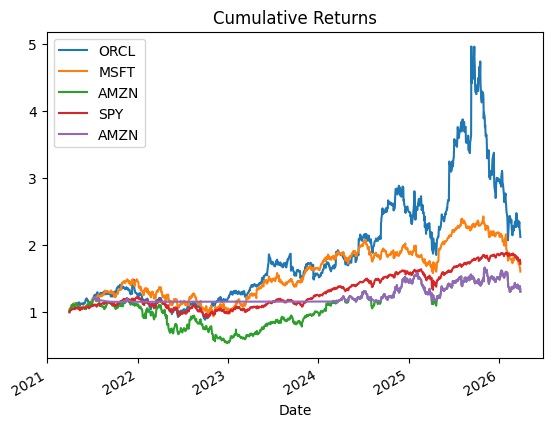

In [9]:
df_orcl['Cumm_Return'] = (1 + df_orcl['Daily_Return']).cumprod()
df_msft['Cumm_Return'] = (1 + df_msft['Daily_Return']).cumprod()
df_amzn['Cumm_Return'] = (1 + df_amzn['Daily_Return']).cumprod()
df_spy['Cumm_Return'] = (1 + df_spy['Daily_Return']).cumprod()
threshold = 1.15

df_orcl['Cumm_Return'].plot(label='ORCL')
df_msft['Cumm_Return'].plot(label='MSFT')
df_amzn['Cumm_Return'].plot(label='AMZN')
df_spy['Cumm_Return'].plot(label='SPY')

amzn_cum_return = df_amzn['Cumm_Return'][df_amzn['Cumm_Return'] > threshold]
amzn_cum_return.plot(label='AMZN')

plt.title('Cumulative Returns')
plt.legend()
plt.show()

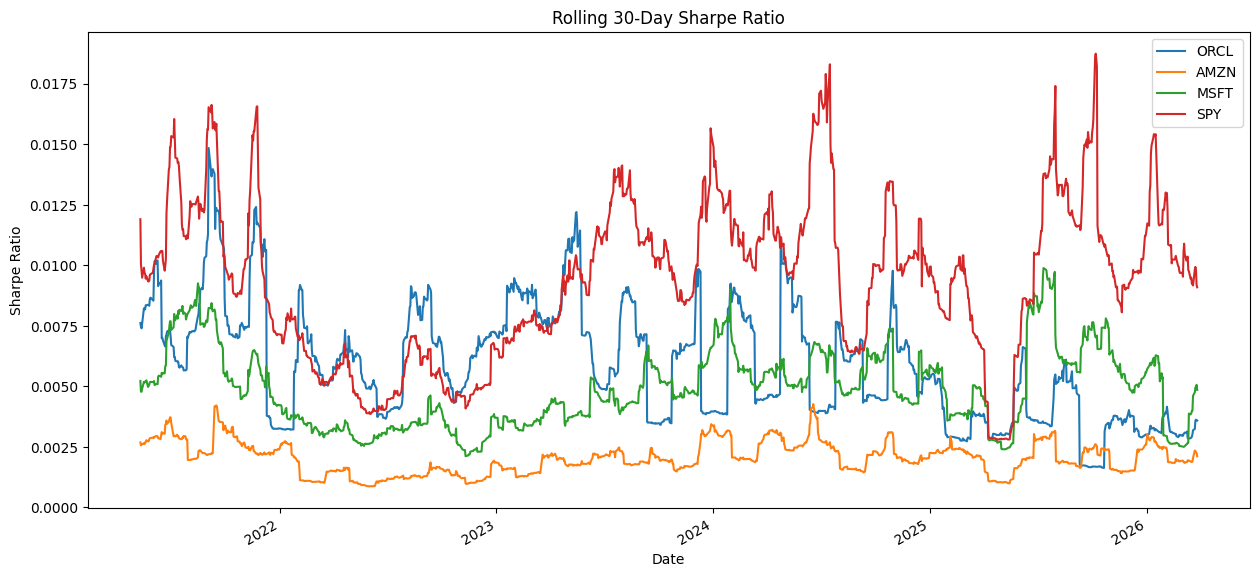

In [10]:
TRADING_DAYS = 30
returns = np.log(df_orcl['Close']/df_orcl['Close'].shift(1))
returns.fillna(0, inplace=True)
volatility = returns.rolling(window=TRADING_DAYS).std()*np.sqrt(TRADING_DAYS)
sharpe_ratio_orcl = returns.mean() / volatility

returns = np.log(df_amzn['Close']/df_amzn['Close'].shift(1))
returns.fillna(0, inplace=True)
volatility = returns.rolling(window=TRADING_DAYS).std()*np.sqrt(TRADING_DAYS)
sharpe_ratio_amzn = returns.mean() / volatility

returns = np.log(df_spy['Close']/df_spy['Close'].shift(1))
returns.fillna(0, inplace=True)
volatility = returns.rolling(window=TRADING_DAYS).std()*np.sqrt(TRADING_DAYS)
sharpe_ratio_spy = returns.mean() / volatility

returns = np.log(df_msft['Close']/df_msft['Close'].shift(1))
returns.fillna(0, inplace=True)
volatility = returns.rolling(window=TRADING_DAYS).std()*np.sqrt(TRADING_DAYS)
sharpe_ratio_msft = returns.mean() / volatility

fig = plt.figure(figsize=(15, 7))
ax3 = fig.add_subplot(1, 1, 1)
sharpe_ratio_orcl.plot(ax=ax3, label='ORCL')
sharpe_ratio_amzn.plot(ax=ax3, label='AMZN')
sharpe_ratio_msft.plot(ax=ax3, label='MSFT')
sharpe_ratio_spy.plot(ax=ax3, label='SPY')
ax3.set_xlabel('Date')
ax3.set_ylabel('Sharpe Ratio')
ax3.legend()
ax3.set_title('Rolling 30-Day Sharpe Ratio')
plt.show()

In [11]:
import quantstats as qs

# extend pandas functionality with metrics, etc.
qs.extend_pandas()

# fetch the daily returns for a stock
ticker_list=['ORCL','MSFT','AMZN','SPY']
stock = qs.utils.download_returns(ticker_list,period="5y")

# show sharpe ratio
qs.stats.sharpe(stock)

# or using extend_pandas()
stock.sharpe()

,0
Ticker,
AMZN,0.323727
MSFT,0.481836
ORCL,0.566563
SPY,0.721514


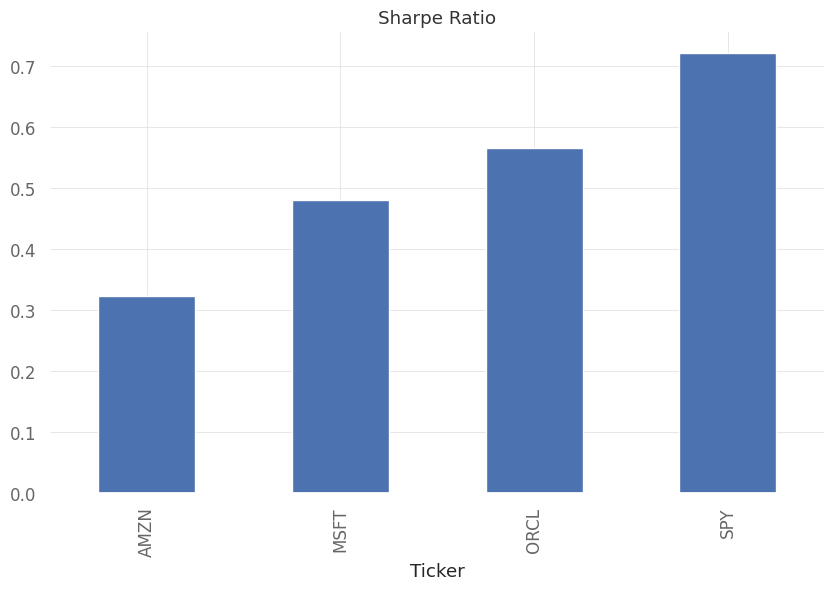

In [12]:
stock.sharpe().plot.bar(title='Sharpe Ratio')
plt.show()

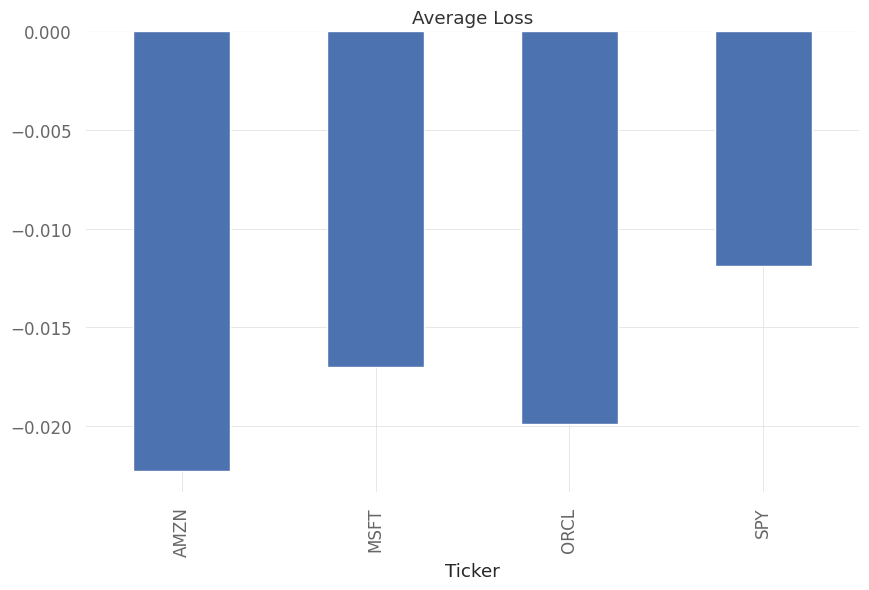

In [13]:
stock.avg_loss().plot.bar(title='Average Loss')
plt.show()

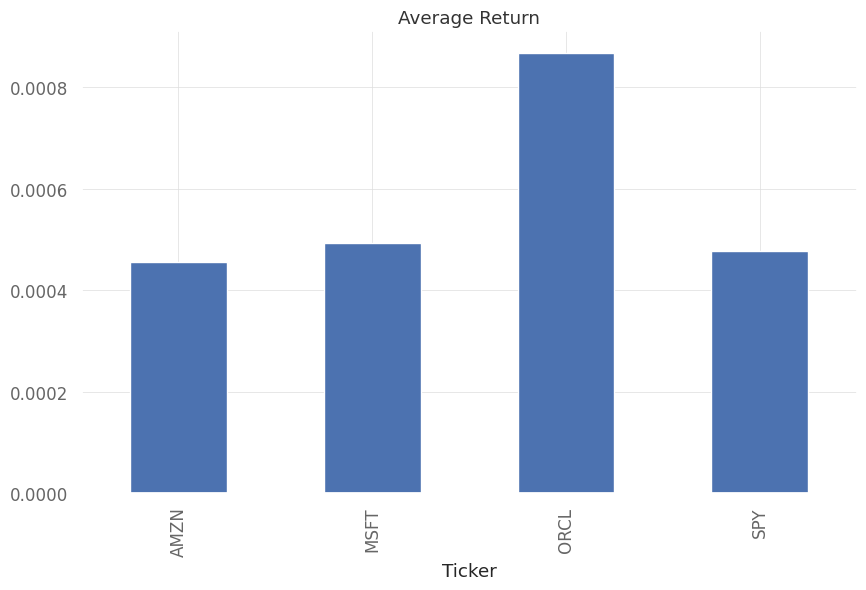

In [14]:
stock.avg_return().plot.bar(title='Average Return')
plt.show()

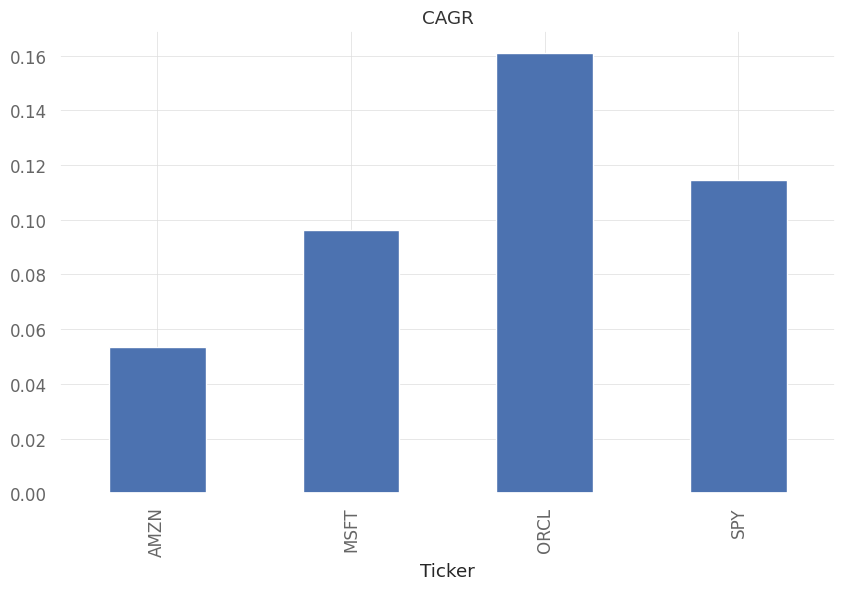

In [15]:
stock.cagr().plot.bar(title='CAGR')
plt.show()

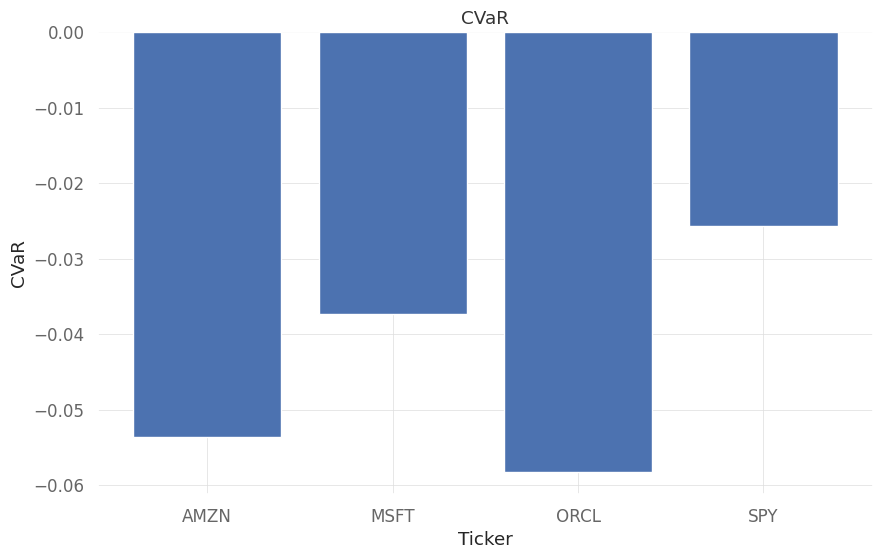

In [16]:
tickers = ['AMZN', 'MSFT', 'ORCL', 'SPY']
cvar = qs.stats.cvar(stock)

plt.bar(tickers, cvar)
plt.title('CVaR')
plt.xlabel('Ticker')
plt.ylabel('CVaR')
plt.show()

In [17]:
qs.stats.sharpe(stock)

,0
Ticker,
AMZN,0.323727
MSFT,0.481836
ORCL,0.566563
SPY,0.721514


In [18]:
qs.stats.avg_loss(stock)

,0
Ticker,
AMZN,-0.022308
MSFT,-0.017004
ORCL,-0.019891
SPY,-0.011901


In [19]:
qs.stats.avg_return(stock)

,0
Ticker,
AMZN,0.000456
MSFT,0.000494
ORCL,0.000867
SPY,0.000478


In [20]:
qs.stats.kelly_criterion(stock)

,0
Ticker,
AMZN,-0.032323
MSFT,-0.035949
ORCL,-0.019011
SPY,0.023373


In [21]:
qs.stats.gain_to_pain_ratio(stock)

,0
Ticker,
AMZN,0.058776
MSFT,0.087995
ORCL,0.121367
SPY,0.137813


In [22]:
qs.stats.max_drawdown(stock)

,0
Ticker,
AMZN,-0.561453
MSFT,-0.371485
ORCL,-0.582499
SPY,-0.244964


In [23]:
qs.stats.risk_return_ratio(stock)

,0
Ticker,
AMZN,0.020393
MSFT,0.030353
ORCL,0.035690
SPY,0.045451


In [24]:
qs.stats.kurtosis(stock)

,0
Ticker,
AMZN,5.073470
MSFT,3.991245
ORCL,37.995440
SPY,9.378174


In [25]:
qs.stats.skew(stock)

,0
Ticker,
AMZN,0.129792
MSFT,0.020459
ORCL,2.508220
SPY,0.316610


In [26]:
qs.stats.sortino(stock)

,0
Ticker,
AMZN,0.467345
MSFT,0.692667
ORCL,0.901302
SPY,1.041727


In [27]:
qs.stats.tail_ratio(stock)

,0
Ticker,
AMZN,1.009561
MSFT,0.938010
ORCL,0.962800
SPY,0.966651


In [28]:
qs.stats.ulcer_performance_index(stock)

,0
Ticker,
AMZN,1.240344
MSFT,4.138771
ORCL,5.629630
SPY,8.478703


In [29]:
qs.stats.win_loss_ratio(stock)

,0
Ticker,
AMZN,0.888281
MSFT,0.868965
ORCL,0.861740
SPY,0.880571


In [30]:
qs.stats.win_rate(stock)

,0
AMZN,0.514377
MSFT,0.518341
ORCL,0.528332
SPY,0.542698


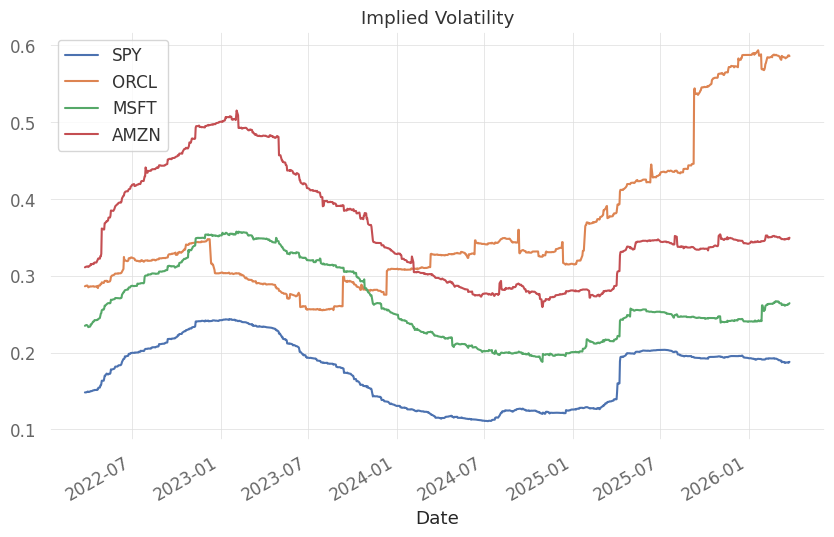

In [31]:
implvol = qs.stats.implied_volatility(stock)

implvol['SPY'].plot(label='SPY')
implvol['ORCL'].plot(label='ORCL')
implvol['MSFT'].plot(label='MSFT')
implvol['AMZN'].plot(label='AMZN')
plt.legend()
plt.title('Implied Volatility')
plt.show()

In [32]:
# Compute correlation matrix
co_mtx = implvol.corr(numeric_only=True)

# Print correlation matrix
display(co_mtx)

Ticker,AMZN,MSFT,ORCL,SPY
Ticker,,,,
AMZN,1.000000,0.975853,-0.240313,0.889776
MSFT,0.975853,1.000000,-0.290711,0.853034
ORCL,-0.240313,-0.290711,1.000000,0.142003
SPY,0.889776,0.853034,0.142003,1.000000


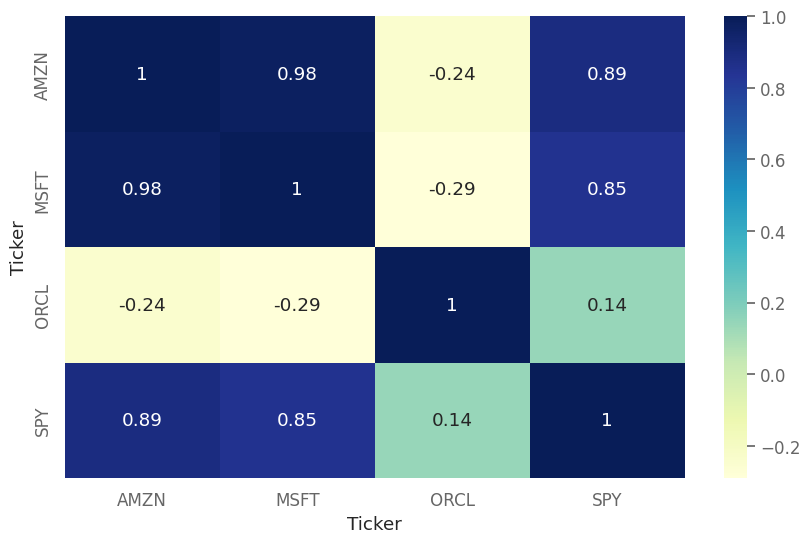

In [33]:
# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

# Display heatmap
plt.show()

In [34]:
# KAMA params
ER_PERIOD = 10       # Efficiency Ratio period
FAST_SC_FAST = 5     # used to compute fast smoothing constant (typical: 2 -> fastest)
FAST_SC_SLOW = 10    # used to compute fast smoothing constant (typical: 30 -> slowest)

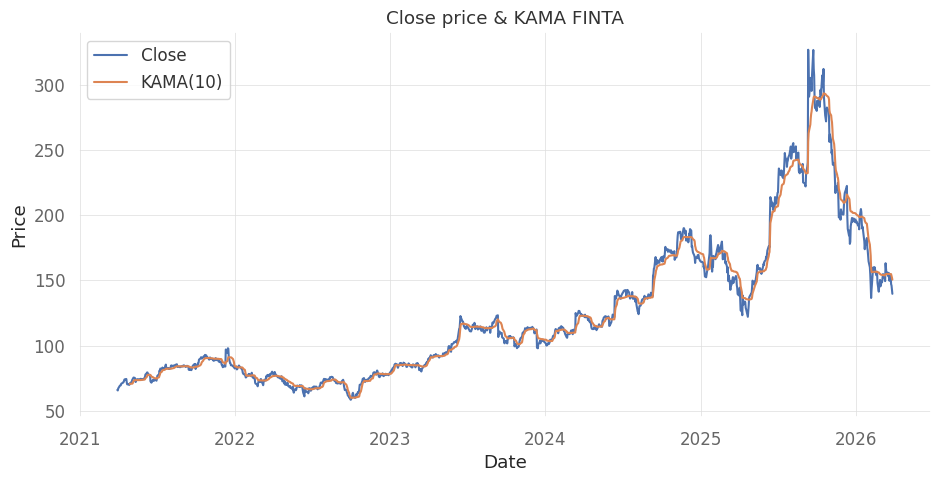

In [35]:
from finta import TA
import pandas_ta as ta

# Monkey-patch Pandas to add iteritems back
if not hasattr(pd.Series, "iteritems"):
    pd.Series.iteritems = pd.Series.items

kama_period = ER_PERIOD
df["KAMAFTA"] = TA.KAMA(df, kama_period)
plt.figure(figsize=(11,5))
plt.plot(df.index, df["Close"], label="Close")
plt.plot(df.index, df["KAMAFTA"], label=f"KAMA({kama_period})")
plt.title("Close price & KAMA FINTA")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

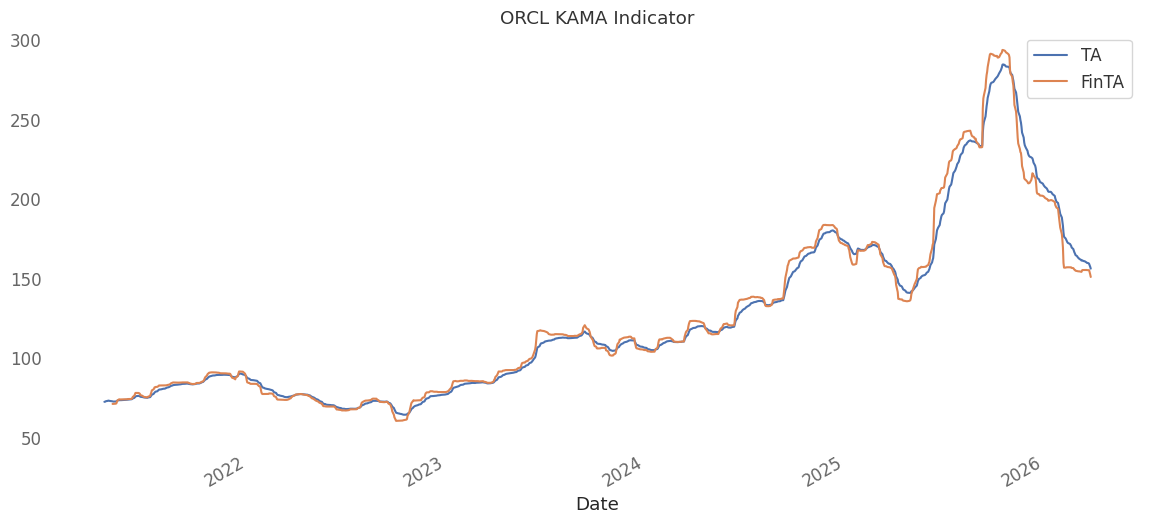

In [36]:
from ta.momentum import kama

# Create KAMA indicator (default window=10, pow1=2, pow2=30)
kamata = kama(close=df["Close"], window=ER_PERIOD, pow1=FAST_SC_FAST, pow2=FAST_SC_SLOW)

# Add KAMA to dataframe
df["KAMATA"] = kamata

# Plotting comparison KAMA TA vs FinTA
plt.figure(figsize=(14,6))
df["KAMATA"].plot(label='TA')
df["KAMAFTA"].plot(label='FinTA')
plt.grid()
plt.legend()
plt.title('ORCL KAMA Indicator')
plt.show()

In [37]:
import pandas_ta as pta

df["KAMAPTA"] = pta.kama(df["Close"], length=ER_PERIOD, fast=FAST_SC_FAST, slow=FAST_SC_SLOW)

display(df[["KAMATA", "KAMAPTA"]].tail())

,KAMATA,KAMAPTA
Date,,
2026-03-23,159.173927,159.173927
2026-03-24,158.740347,158.740347
2026-03-25,157.884174,157.884174
2026-03-26,156.882812,156.882812
2026-03-27,155.757675,155.757675


In [38]:
import talib

df["KAMAtalib"] = talib.KAMA(df["Close"], timeperiod=ER_PERIOD)

display(df[["KAMAFTA", "KAMAtalib"]].tail())

,KAMAFTA,KAMAtalib
Date,,
2026-03-23,154.817218,154.817218
2026-03-24,154.747869,154.747869
2026-03-25,153.533654,153.533654
2026-03-26,152.095294,152.095294
2026-03-27,150.504069,150.504069


In [39]:
def kama_classic(price, er_period=10, fast=2, slow=30):
  price = price.astype(float)
  change = abs(price.diff(er_period))
  volatility = price.diff().abs().rolling(er_period).sum()

  ER = change / volatility
  fastSC = 2 / (fast + 1)
  slowSC = 2 / (slow + 1)

  SC = (ER * (fastSC - slowSC) + slowSC) ** 2

  kama = pd.Series(np.nan, index=price.index)
  kama.iloc[er_period] = price.iloc[er_period]

  for i in range(er_period + 1, len(price)):
      kama.iloc[i] = kama.iloc[i-1] + SC.iloc[i] * (price.iloc[i] - kama.iloc[i-1])
  return kama


price=df['Close']
df['kama_class']=kama_classic(price, er_period=ER_PERIOD, fast=FAST_SC_FAST, slow=FAST_SC_SLOW)

display(df[["KAMATA", "kama_class"]].tail())

,KAMATA,kama_class
Date,,
2026-03-23,159.173927,159.173927
2026-03-24,158.740347,158.740347
2026-03-25,157.884174,157.884174
2026-03-26,156.882812,156.882812
2026-03-27,155.757675,155.757675


In [40]:
def kama_log_er(price, er_period=10, fast=2, slow=30):
  logp = np.log(price)

  change = abs(logp.diff(er_period))
  volatility = logp.diff().abs().rolling(er_period).sum()
  ER = change / volatility

  fastSC = 2 / (fast + 1)
  slowSC = 2 / (slow + 1)
  SC = (ER * (fastSC - slowSC) + slowSC) ** 2

  kama = pd.Series(np.nan, index=price.index)
  kama.iloc[er_period] = price.iloc[er_period]

  for i in range(er_period + 1, len(price)):
      kama.iloc[i] = kama.iloc[i-1] + SC.iloc[i] * (price.iloc[i] - kama.iloc[i-1])
  return kama

df['kama_logret']=kama_log_er(price, er_period=ER_PERIOD, fast=FAST_SC_FAST, slow=FAST_SC_SLOW)

display(df[["kama_class", "kama_logret"]].tail())

,kama_class,kama_logret
Date,,
2026-03-23,159.173927,159.150846
2026-03-24,158.740347,158.716593
2026-03-25,157.884174,157.864192
2026-03-26,156.882812,156.859830
2026-03-27,155.757675,155.723247


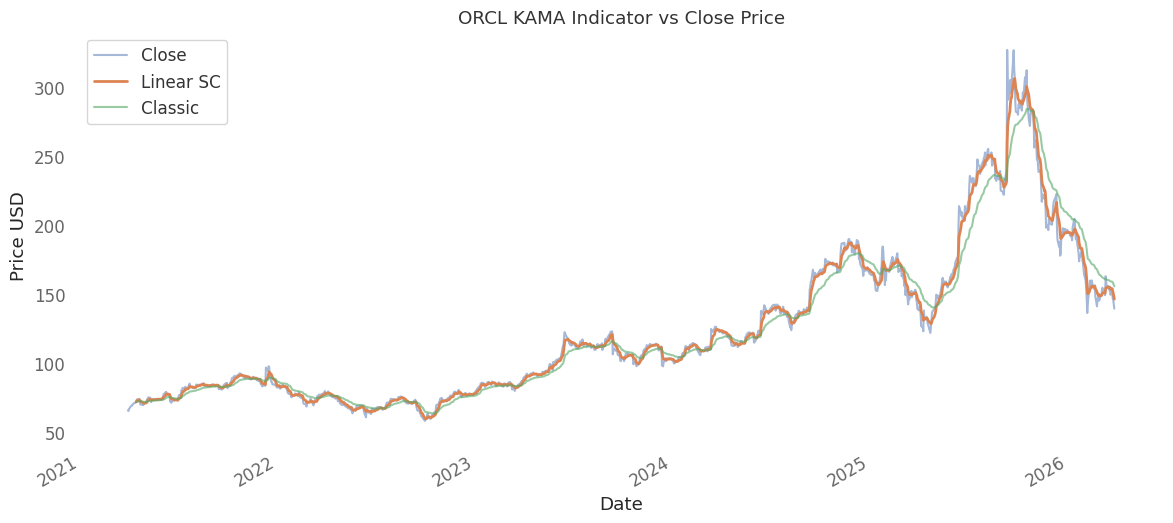

In [41]:
def kama_linear_sc(price, er_period=10, fast=2, slow=30):
  change = abs(price.diff(er_period))
  volatility = price.diff().abs().rolling(er_period).sum()
  ER = change / volatility

  fastSC = 2 / (fast + 1)
  slowSC = 2 / (slow + 1)

  SC = ER * (fastSC - slowSC) + slowSC   # <-- linear, not squared

  kama = pd.Series(np.nan, index=price.index)
  kama.iloc[er_period] = price.iloc[er_period]

  for i in range(er_period + 1, len(price)):
      kama.iloc[i] = kama.iloc[i-1] + SC.iloc[i] * (price.iloc[i] - kama.iloc[i-1])
  return kama

df['kama_linsc']=kama_linear_sc(price, er_period=ER_PERIOD, fast=FAST_SC_FAST, slow=FAST_SC_SLOW)

#Plotting

plt.figure(figsize=(14,6))
df['Close'].plot(label='Close',alpha=0.5)

df['kama_linsc'].plot(label='Linear SC',lw=2)

df['kama_class'].plot(label='Classic',alpha=0.6)

plt.legend()
plt.ylabel('Price USD')
plt.title('ORCL KAMA Indicator vs Close Price')
plt.grid()
plt.show()

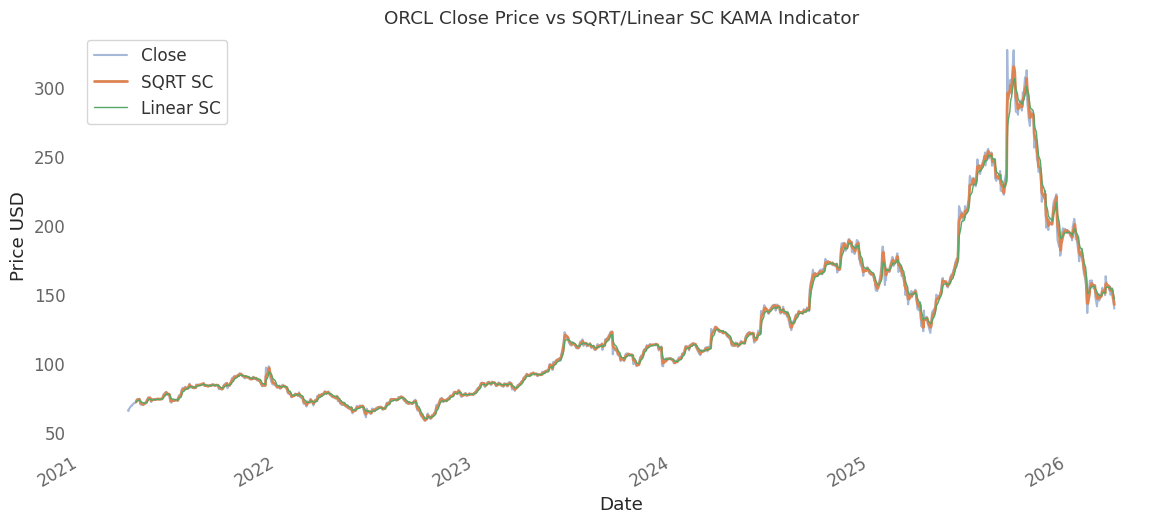

In [42]:
def kama_sqrt_sc(price, er_period=10, fast=2, slow=30):
  change = abs(price.diff(er_period))
  volatility = price.diff().abs().rolling(er_period).sum()
  ER = change / volatility

  fastSC = 2 / (fast + 1)
  slowSC = 2 / (slow + 1)

  SC = np.sqrt(ER * (fastSC - slowSC) + slowSC)

  kama = pd.Series(np.nan, index=price.index)
  kama.iloc[er_period] = price.iloc[er_period]

  for i in range(er_period + 1, len(price)):
      kama.iloc[i] = kama.iloc[i-1] + SC.iloc[i] * (price.iloc[i] - kama.iloc[i-1])
  return kama

df['kama_sqrtsc']=kama_sqrt_sc(price, er_period=ER_PERIOD, fast=FAST_SC_FAST, slow=FAST_SC_SLOW)

#Plotting

plt.figure(figsize=(14,6))
df['Close'].plot(label='Close',alpha=0.5)
df['kama_sqrtsc'].plot(label='SQRT SC',lw=2)
df['kama_linsc'].plot(label='Linear SC',lw=1)

plt.legend()
plt.ylabel('Price USD')
plt.title('ORCL Close Price vs SQRT/Linear SC KAMA Indicator')
plt.grid()
plt.show()

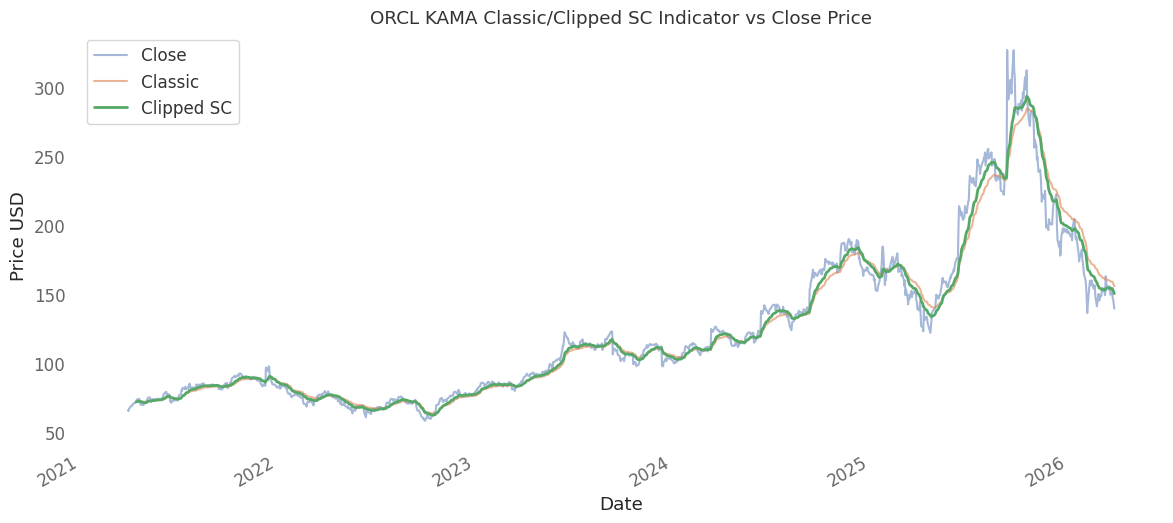

In [43]:
def kama_clipped_sc(price, er_period=10, fast=2, slow=30, minSC=0.01, maxSC=0.5):
  change = abs(price.diff(er_period))
  volatility = price.diff().abs().rolling(er_period).sum()
  ER = change / volatility

  fastSC = 2 / (fast + 1)
  slowSC = 2 / (slow + 1)

  SC = (ER * (fastSC - slowSC) + slowSC) ** 2
  SC = SC.clip(minSC, maxSC)

  kama = pd.Series(np.nan, index=price.index)
  kama.iloc[er_period] = price.iloc[er_period]

  for i in range(er_period + 1, len(price)):
      kama.iloc[i] = kama.iloc[i-1] + SC.iloc[i] * (price.iloc[i] - kama.iloc[i-1])
  return kama

df['kama_clippedsc']=kama_clipped_sc(price, er_period=ER_PERIOD, fast=FAST_SC_FAST, slow=FAST_SC_SLOW,minSC=0.1, maxSC=0.3)

# Plotting

plt.figure(figsize=(14,6))
df['Close'].plot(label='Close',alpha=0.5)

df['kama_class'].plot(label='Classic',alpha=0.6)
df['kama_clippedsc'].plot(label='Clipped SC',lw=2)
plt.legend()
plt.ylabel('Price USD')
plt.title('ORCL KAMA Classic/Clipped SC Indicator vs Close Price')
plt.grid()
plt.show()

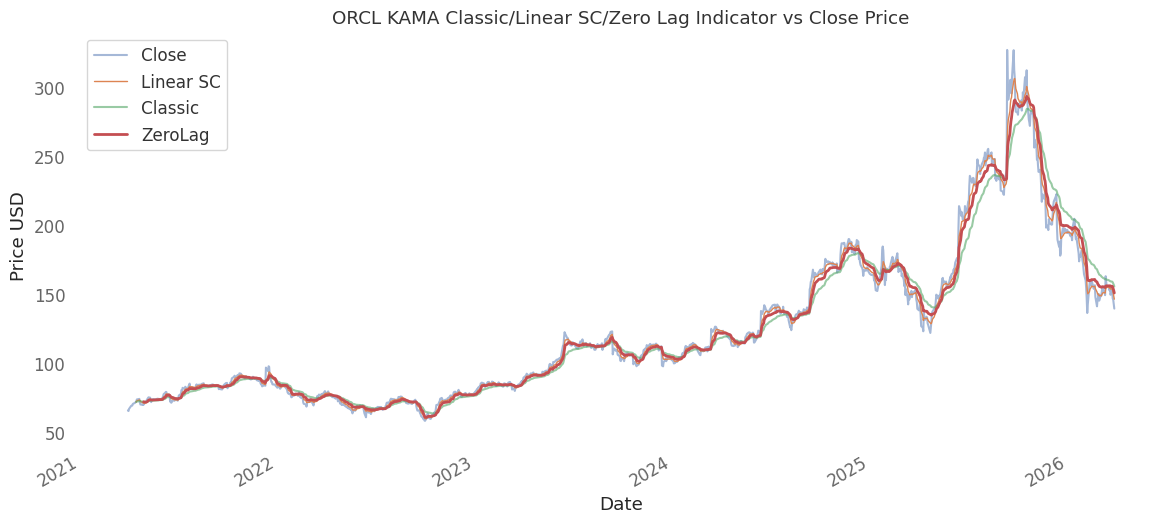

In [44]:
def kama_zero_lag(price, er_period=10, fast=2, slow=30):
  kama1 = kama_classic(price, er_period, fast, slow)
  kama2 = kama_classic(kama1.dropna(), er_period, fast, slow)
  kama2 = kama2.reindex(price.index)

  return kama1 + (kama1 - kama2)

df['kama_zerolag']=kama_zero_lag(price, er_period=ER_PERIOD, fast=FAST_SC_FAST, slow=FAST_SC_SLOW)

#Plotting

plt.figure(figsize=(14,6))
df['Close'].plot(label='Close',alpha=0.5)

df['kama_linsc'].plot(label='Linear SC',lw=1)

df['kama_class'].plot(label='Classic',alpha=0.6)
df['kama_zerolag'].plot(label='ZeroLag',lw=2)
plt.legend()
plt.ylabel('Price USD')
plt.title('ORCL KAMA Classic/Linear SC/Zero Lag Indicator vs Close Price')
plt.grid()
plt.show()

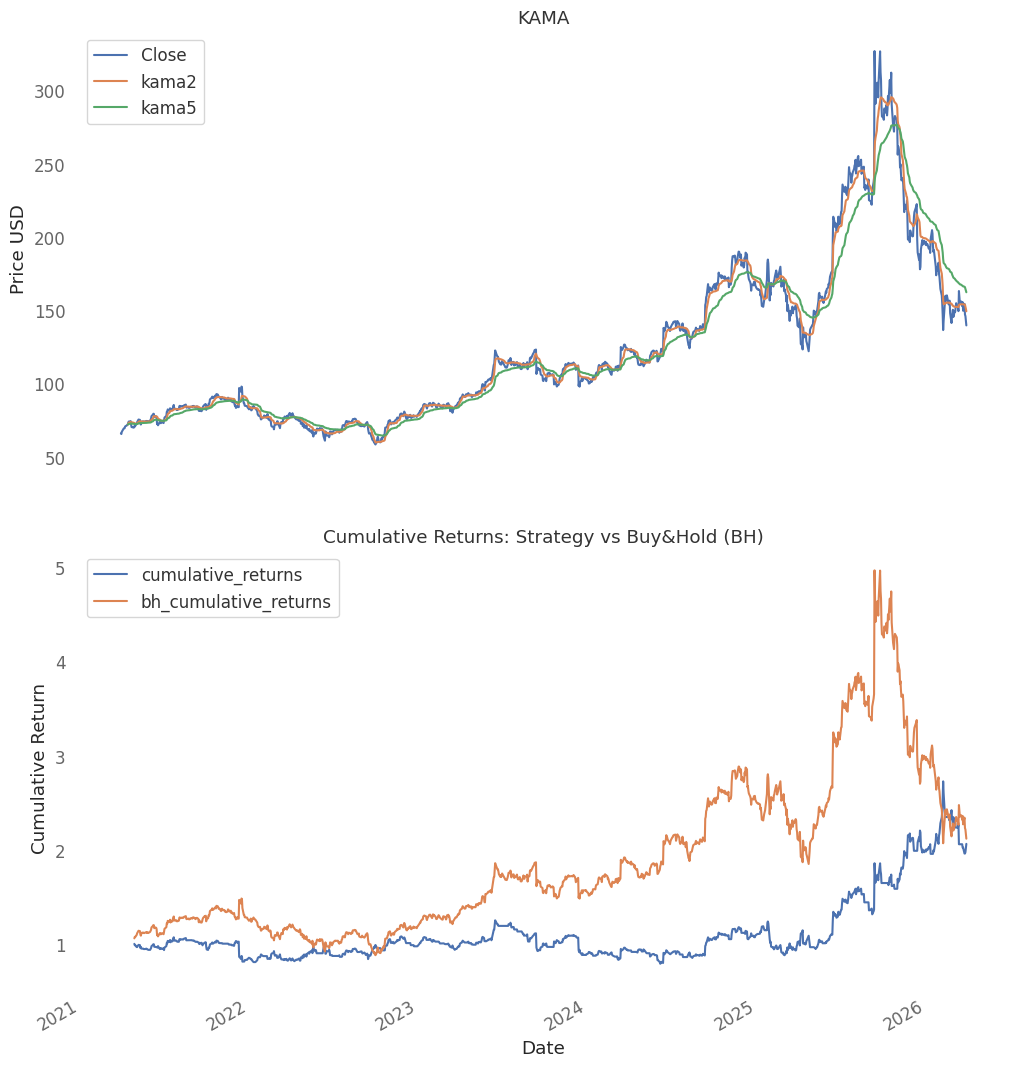

In [45]:
period = 10
period_fast = 2
period_slow = 15
period_fast1 = 5

close = df['Close']

kama2 = kama_classic(close, period, period_fast, period_slow)
df['kama2'] = kama2

kama5 = kama_classic(close, period, period_fast1, period_slow)
df['kama5'] = kama5

kama_roc = df['kama5'].pct_change()

# Calculate the signal
df['signal'] = np.where((kama_roc>0) & (close >= kama2),1,np.where((kama_roc<0) & (close <= kama2),-1,0))

#*********************************RETURN********************************
df['signal_shifted'] = df['signal'].shift()

buy_signals = df[df["signal_shifted"] == 1]
sell_signals = df[df["signal_shifted"] == -1]

# Calculate the returns on the days we trigger a signal
df['returns'] = df['Close'].pct_change()

# Calculate the strategy returns
df['strategy_returns'] = df['signal_shifted'] * df['returns']

# Calculate the cumulative returns
df1 = df.dropna()
df1['cumulative_returns'] = (1 + df1['strategy_returns']).cumprod()
df1['bh_cumulative_returns'] = (1 + df['returns']).cumprod()

df_concat = pd.concat((df[['Close','kama2','kama5','signal']],df1[['cumulative_returns']]),axis=1)

#*********************************PLOT**********************************
figsize=(12,14)
fig, (ax0,ax1) = plt.subplots(nrows=2, sharex=True, subplot_kw=dict(frameon=True),figsize=figsize)

df_concat[['Close','kama2','kama5']].plot(ax=ax0)
ax0.set_title("KAMA")
ax0.set_ylabel('Price USD')
ax0.grid()

df_concat[['cumulative_returns']].plot(ax=ax1)
df1['bh_cumulative_returns'].plot(ax=ax1)
ax1.legend()
ax1.set_title("Cumulative Returns: Strategy vs Buy&Hold (BH)")
ax1.set_ylabel('Cumulative Return')
ax1.grid()
plt.show()

In [46]:
def compute_metrics_from_returns(df,myreturns):
  ret = df[myreturns]

  # Equity curve
  equity = (1 + ret).cumprod()

  # Total Return
  total_return = equity.iloc[-1] - 1

  # Years
  years = (df.index[-1] - df.index[0]).days / 365.25

  # CAGR
  cagr = (equity.iloc[-1]) ** (1 / years) - 1

  # Volatility (annualized)
  vol = ret.std() * np.sqrt(252)

  # Sharpe ratio (rf=0)
  sharpe = cagr / vol

  # Downside volatility for Sortino
  downside = ret[ret < 0]
  sortino = cagr / (downside.std() * np.sqrt(252))

  # Max drawdown
  rolling_peak = equity.cummax()
  drawdown = (equity - rolling_peak) / rolling_peak
  max_dd = drawdown.min()

  # Calmar ratio
  calmar = cagr / abs(max_dd)

  return {
      'Total Return': total_return,
      'CAGR': cagr,
      'Volatility': vol,
      'Sharpe': sharpe,
      'Sortino': sortino,
      'Max Drawdown': max_dd,
      'Calmar': calmar
  }

# Strategy

metrics = compute_metrics_from_returns(df, 'strategy_returns')
for k, v in metrics.items():
  print(f"{k:<15}: {v:.4f}")

Total Return   : 1.0591
CAGR           : 0.1557
Volatility     : 0.3723
Sharpe         : 0.4182
Sortino        : 0.5059
Max Drawdown   : -0.3665
Calmar         : 0.4249


In [47]:
metrics = compute_metrics_from_returns(df, 'returns')
for k, v in metrics.items():
  print(f"{k:<15}: {v:.4f}")

Total Return   : 1.1198
CAGR           : 0.1625
Volatility     : 0.3996
Sharpe         : 0.4066
Sortino        : 0.6062
Max Drawdown   : -0.5825
Calmar         : 0.2789


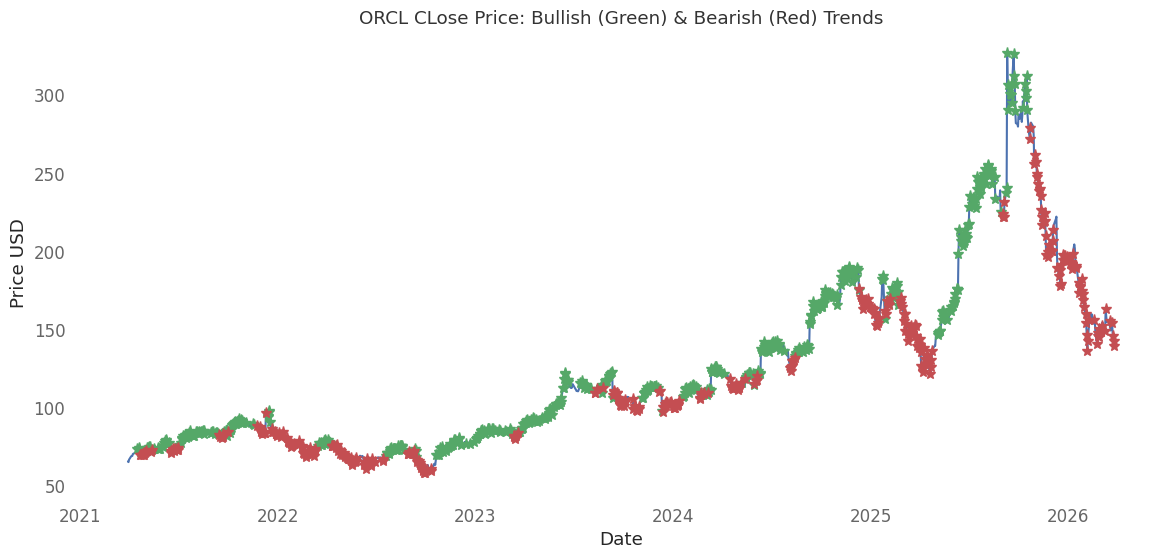

In [48]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df.Close, label='Close')

for idx in buy_signals.index.tolist():
  plt.plot(
      idx,
      df.loc[idx]["Close"],
      "g*",
      markersize=8
  )

for idx in sell_signals.index.tolist():
  plt.plot(
      idx,
      df.loc[idx]["Close"],
      "r*",
      markersize=8
  )
plt.title('ORCL CLose Price: Bullish (Green) & Bearish (Red) Trends')
plt.xlabel('Date')
plt.ylabel('Price USD')
plt.grid()
plt.show()

In [49]:
import talib

def kama_strategy_backtest(close, fast_period, slow_period):
  df = pd.DataFrame({'Close': close})
  df['pct_change'] = df['Close'].pct_change()
  df['fast_sma'] = talib.KAMA(df["Close"], timeperiod=fast_period)
  df['slow_sma'] = talib.KAMA(df["Close"], timeperiod=slow_period)

  # Generate signal
  df['signal'] = 0
  df.loc[(df['fast_sma'] > df['slow_sma']), 'signal'] = 1
  df.loc[(df['fast_sma'] < df['slow_sma']), 'signal'] = -1

  # Calculate returns with shift to avoid lookahead bias
  df['strategy_return'] = df['pct_change'] * df['signal'].shift(1)
  df['equity'] = 100 * (1 + df['strategy_return']).cumprod()

  # Calculate Buy and Hold total return in percentage
  df['bnh_equity'] = 100 * (1 + df['pct_change']).cumprod()
  bnh_total_ret = (df['bnh_equity'].iloc[-1] / df['bnh_equity'].dropna().iloc[0] - 1) * 100

  # Strategy total return
  equity = df['equity']
  total_ret = (equity.iloc[-1] / equity.dropna().iloc[0] - 1) * 100

  return equity, total_ret, bnh_total_ret

fast_period = 5
slow_period = 10

price = df.Close

equity, total_ret, bnh_total_ret = kama_strategy_backtest(price, fast_period, slow_period)

print("Total return (%):", total_ret)
print("Buy and Hold return (%):", bnh_total_ret)

Total return (%): 114.37603860530446
Buy and Hold return (%): 113.13027091057015


In [50]:
from itertools import product

def optimize_kama_periods(close, fast_range, slow_range):
  best_result = {'fast': None, 'medium': None, 'slow': None, 'total_return': -np.inf}
  best_equity = None

  # Iterate valid combinations: fast < medium < slow
  for fast, slow in product(fast_range, slow_range):
      if fast < slow:
          equity, total_ret, bnh_total_ret = kama_strategy_backtest(close, fast, slow)
          if total_ret > best_result['total_return']:
              best_result = {'fast': fast, 'slow': slow, 'total_return': total_ret}
              best_equity = equity
              buy_and_hold = bnh_total_ret

  return {
      'best_periods': (best_result['fast'], best_result['slow']),
      'best_total_return': best_result['total_return'],
      'best_equity': best_equity,
      'buy_and_hold': buy_and_hold
  }

fast_range = range(5, 46, 5)
slow_range = range(10, 150, 10)

result = optimize_kama_periods(price, fast_range, slow_range)
print("Best periods (fast, slow):", result['best_periods'])
print("Best total return (%):", result['best_total_return'])
print("Buy and Hold return (%):", result['buy_and_hold'])

Best periods (fast, slow): (35, 120)
Best total return (%): 407.4278002477384
Buy and Hold return (%): 113.13027091057015


In [51]:
# Train Dataset

from_date_train = '2022-01-03'
to_date_train = '2025-04-30'

df_train = df.loc[from_date_train:to_date_train]

result = optimize_kama_periods(df_train['Close'], fast_range, slow_range)

best_fast = result['best_periods'][0]
best_slow = result['best_periods'][1]

print("Best periods (fast, slow):", best_fast, best_slow)
print("Best total return (%):", result['best_total_return'])
print("Buy and Hold return (%):", result['buy_and_hold'])

Best periods (fast, slow): 40 70
Best total return (%): 92.26834399234424
Buy and Hold return (%): 66.5974488659977


In [52]:
# Test Dataset

from_date_test = '2025-05-01'
to_date_test = '2025-11-26'

df_test = df.loc[from_date_test:to_date_test]
equity,total_ret, bnh_total_ret = kama_strategy_backtest(df_test['Close'], best_fast, best_slow)

print("Best periods applied (fast, medium, slow):", best_fast, best_slow)
print("Total return (%):", total_ret)
print("Buy and Hold return (%):", bnh_total_ret)

Best periods applied (fast, medium, slow): 40 70
Total return (%): 101.12534400696819
Buy and Hold return (%): 36.50366058586485


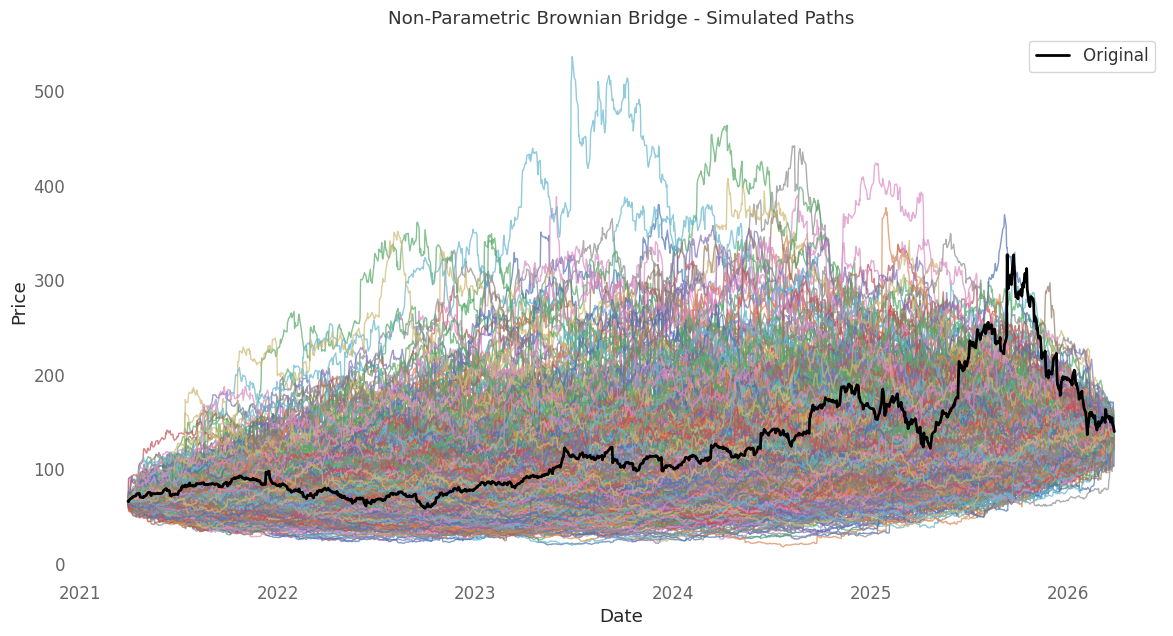

In [53]:
close_prices = df['Close']

def non_parametric_brownian_bridge(close_prices, n_paths=1000, seed=42):
  np.random.seed(seed)
  n = len(close_prices)
  X0 = np.log(close_prices.iloc[0])
  Xn = np.log(close_prices.iloc[-1])
  log_returns = np.log(close_prices / close_prices.shift(1)).dropna().values

  paths = np.zeros((n, n_paths))
  for i in range(n_paths):
      # Sample n-1 returns and center them
      sampled = np.random.choice(log_returns, size=n - 1, replace=True)
      drift_correction = (Xn - X0) / (n - 1) - np.mean(sampled)
      sampled += drift_correction  # Center drift
      W = np.concatenate(([0], np.cumsum(sampled)))  # Now length n
      # Brownian bridge formula for all time steps (n)
      bridge = X0 + W + np.linspace(0, 1, n) * (Xn - X0 - W[-1])
      paths[:, i] = bridge

  sim_prices = np.exp(paths)
  sim_prices[~np.isfinite(sim_prices)] = np.nan
  return sim_prices


simulated_paths = non_parametric_brownian_bridge(close_prices, n_paths=1000)

for i in range(simulated_paths.shape[1]):
    df[f'sim_path_{i+1}'] = simulated_paths[:, i]

plt.figure(figsize=(14, 7))
plt.plot(df.index, df.loc[:, 'sim_path_1':'sim_path_1000'], lw=1, alpha=0.7)
plt.plot(df.index, close_prices, lw=2, label='Original', color='black')
plt.title('Non-Parametric Brownian Bridge - Simulated Paths')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid()
plt.legend()
plt.show()

In [54]:
from tqdm import tqdm
import talib

df_train_multiple_paths = df.loc[from_date_train:to_date_train]

results = []

def sma_strategy_backtest(close, fast, slow):
    # Ensure data is clean for TA-Lib
    s = pd.Series(close).dropna()
    if len(s) < slow:
        return None, -100, -100

    df_bt = pd.DataFrame({'Close': s})
    df_bt['pct_change'] = df_bt['Close'].pct_change()

    # Calculate SMAs
    df_bt['fast_sma'] = talib.SMA(df_bt['Close'], timeperiod=int(fast))
    df_bt['slow_sma'] = talib.SMA(df_bt['Close'], timeperiod=int(slow))

    # Generate Signals: 1 for Long, -1 for Short
    df_bt['signal'] = 0
    df_bt.loc[df_bt['fast_sma'] > df_bt['slow_sma'], 'signal'] = 1
    df_bt.loc[df_bt['fast_sma'] < df_bt['slow_sma'], 'signal'] = -1

    # Calculate Returns (shifted signal to avoid look-ahead bias)
    df_bt['strategy_return'] = df_bt['pct_change'] * df_bt['signal'].shift(1)

    # Calculate Cumulative Equity
    equity = (1 + df_bt['strategy_return'].fillna(0)).cumprod()

    # Total Returns in percentage
    total_backtest_ret = (equity.iloc[-1] - 1) * 100
    bnh_ret = (df_bt['Close'].iloc[-1] / df_bt['Close'].iloc[0] - 1) * 100

    return equity, total_backtest_ret, bnh_ret

# Run simulation across paths
# Reduced range or optimized loop might be needed for very large n_paths
for i in tqdm(range(1, 1001, 1)):
    path_col = f'sim_path_{i}'
    for fast, slow in product(fast_range, slow_range):
        if fast < slow:
            _, total_backtest_ret, _ = sma_strategy_backtest(df_train_multiple_paths[path_col], fast, slow)
            results.append({'path': i, 'fast': fast, 'slow': slow, 'total_return': total_backtest_ret})

df_all_paths_train = pd.DataFrame(results)
if not IN_COLAB:
  df_all_paths_train.to_csv('df_all_paths_train.csv', index=False)
display(df_all_paths_train.head())

100%|██████████| 1000/1000 [07:08<00:00,  2.33it/s]


,path,fast,slow,total_return
0,1,5,10,-44.697155
1,1,5,20,1.963248
2,1,5,30,-2.251177
3,1,5,40,33.729674
4,1,5,50,-36.483401


In [55]:
unique_combos = (
    df_all_paths_train[['fast', 'slow']]
    .drop_duplicates()
    .copy()
)

unique_combos[['fast', 'slow']] = unique_combos[['fast', 'slow']].astype(int)

def _compute_test_metrics(row):
    f, s = int(row['fast']), int(row['slow'])
    _, total_ret, bnh_ret = sma_strategy_backtest(df_test['Close'], f, s)
    return pd.Series({'test_total_return': total_ret, 'test_bnh_return': bnh_ret})

# Evaluate each unique combo once
unique_combos[['test_total_return', 'test_bnh_return']] = unique_combos.apply(_compute_test_metrics, axis=1)

# Join back to all rows to align with every path's chosen combo
df_all_paths_with_test = df_all_paths_train.merge(unique_combos, on=['fast', 'slow'], how='left')
display(df_all_paths_with_test)

,path,fast,slow,total_return,test_total_return,test_bnh_return
0,1,5,10,-44.697155,-7.166897,41.419993
1,1,5,20,1.963248,0.211208,41.419993
2,1,5,30,-2.251177,-19.993328,41.419993
3,1,5,40,33.729674,-22.107544,41.419993
4,1,5,50,-36.483401,-38.551564,41.419993
...,...,...,...,...,...,...
105995,1000,45,100,-78.053752,-34.577414,41.419993
105996,1000,45,110,-77.637658,-27.766784,41.419993
105997,1000,45,120,-82.479579,-25.509720,41.419993
105998,1000,45,130,-82.732865,-17.411448,41.419993


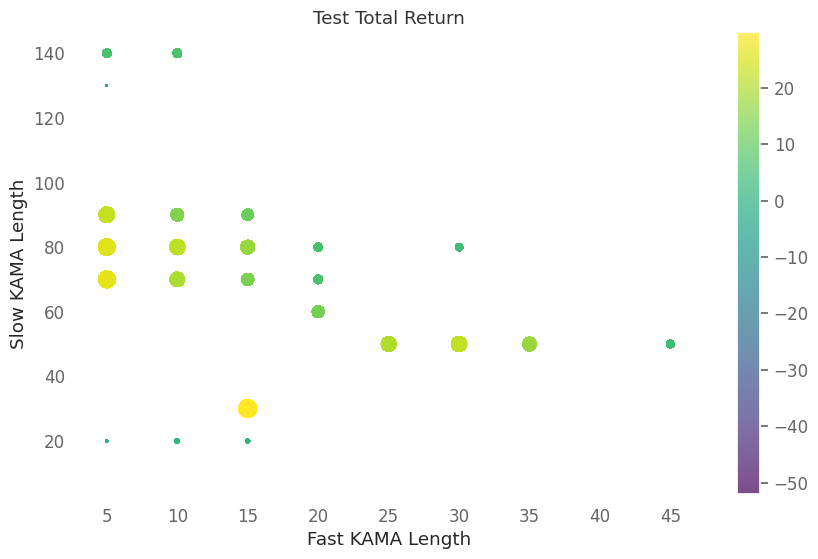

In [56]:
plt.scatter(df_all_paths_with_test['fast'],
                     df_all_paths_with_test['slow'],c=df_all_paths_with_test['test_total_return'],
                     cmap='viridis', s=df_all_paths_with_test['test_total_return']*5,
                     alpha=0.7)
plt.xlabel('Fast KAMA Length')
plt.ylabel('Slow KAMA Length')
plt.title('Test Total Return')
plt.colorbar()
plt.grid()
plt.show()

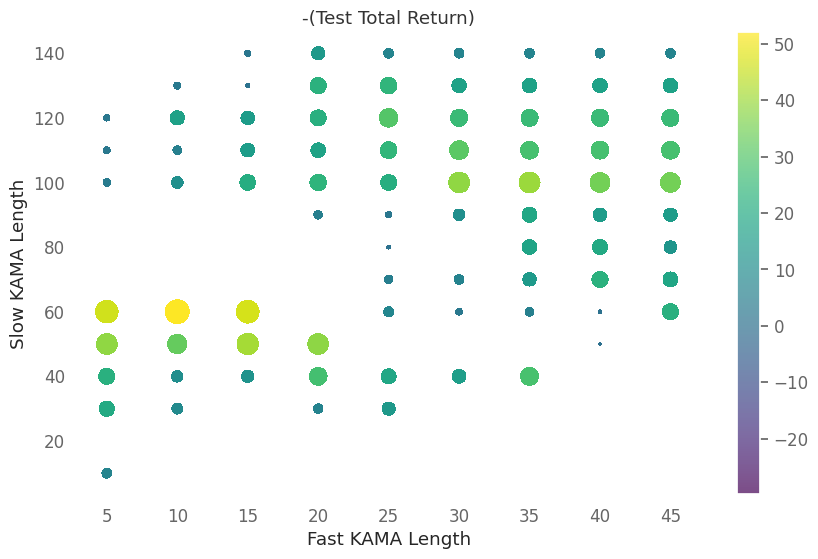

In [57]:
plt.scatter(df_all_paths_with_test['fast'],
                     df_all_paths_with_test['slow'],c=-df_all_paths_with_test['test_total_return'],
                     cmap='viridis', s=-df_all_paths_with_test['test_total_return']*5,
                     alpha=0.7)
plt.xlabel('Fast KAMA Length')
plt.ylabel('Slow KAMA Length')
plt.title('-(Test Total Return)')
plt.colorbar()
plt.grid()
plt.show()

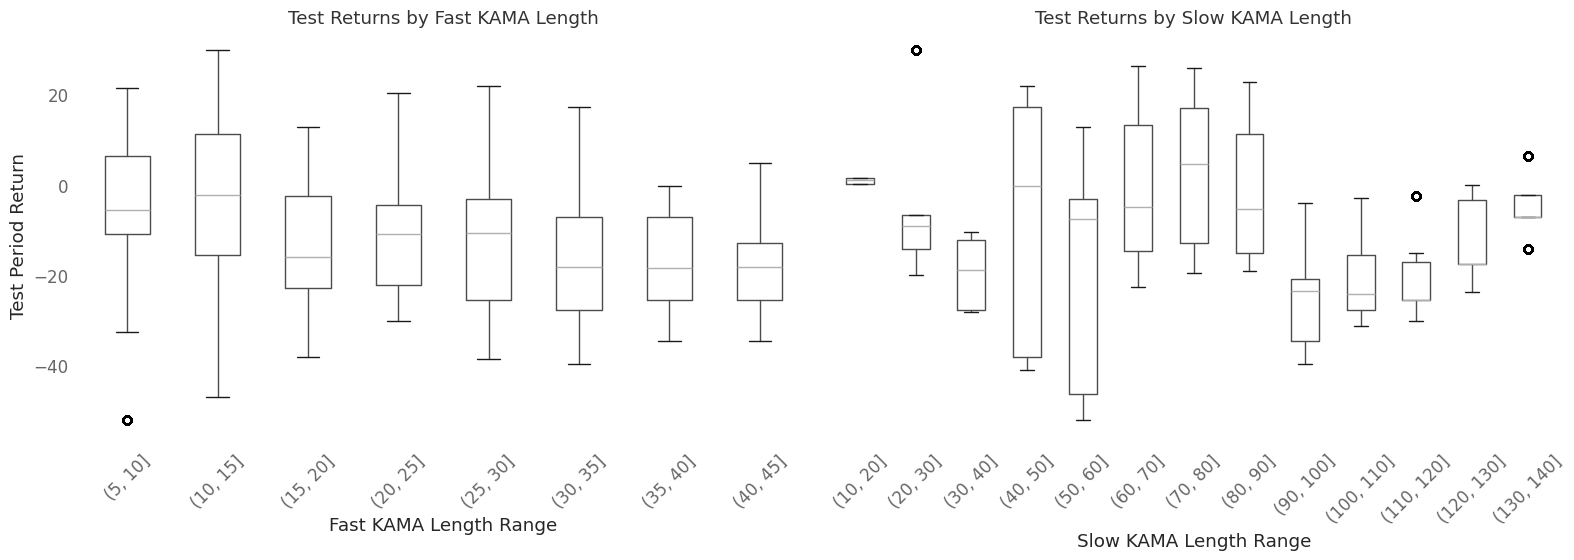

In [58]:
fast_bins = np.arange(df_all_paths_with_test['fast'].min(),
                      df_all_paths_with_test['fast'].max() + 5, 5)
slow_bins = np.arange(df_all_paths_with_test['slow'].min(),
                      df_all_paths_with_test['slow'].max() + 10, 10)

# Create binned columns for fast and slow
df_all_paths_with_test['fast_bin'] = pd.cut(df_all_paths_with_test['fast'], fast_bins)
df_all_paths_with_test['slow_bin'] = pd.cut(df_all_paths_with_test['slow'], slow_bins)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Boxplot for fast parameter bins
df_all_paths_with_test.boxplot(column='test_total_return', by='fast_bin', ax=axes[0], grid=False)
axes[0].set_title('Test Returns by Fast KAMA Length')
axes[0].set_xlabel('Fast KAMA Length Range')
axes[0].set_ylabel('Test Period Return')
axes[0].tick_params(axis='x', rotation=45)

# Boxplot for slow parameter bins
df_all_paths_with_test.boxplot(column='test_total_return', by='slow_bin', ax=axes[1], grid=False)
axes[1].set_title('Test Returns by Slow KAMA Length')
axes[1].set_xlabel('Slow KAMA Length Range')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('')  # Remove default pandas title
plt.tight_layout()
plt.show()

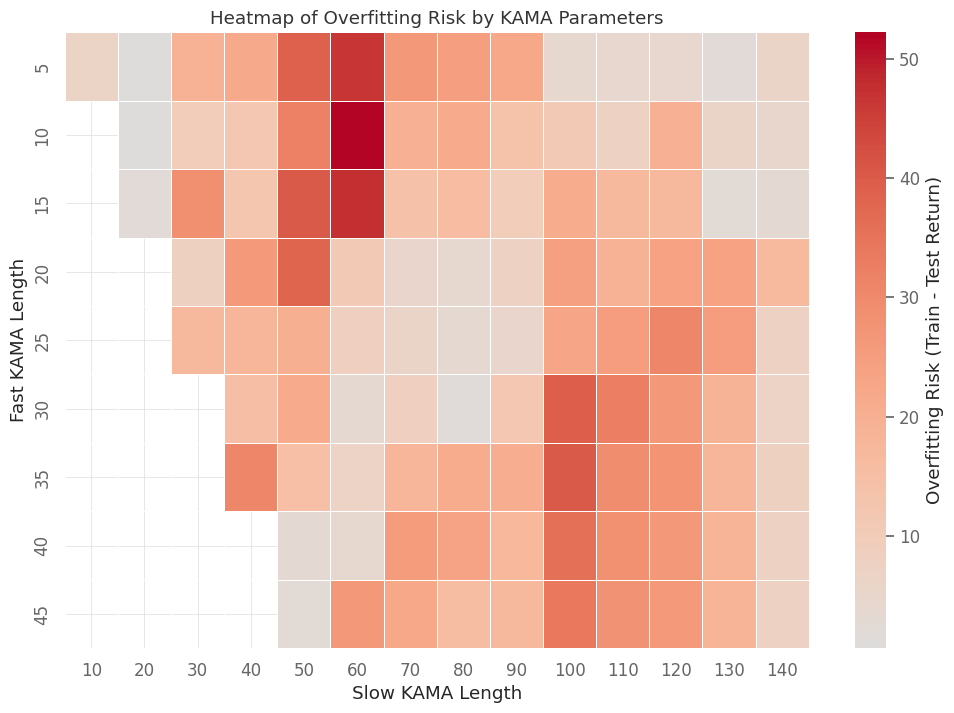

In [59]:
df_all_paths_with_test['overfit'] = df_all_paths_with_test['total_return'] - df_all_paths_with_test['test_total_return']

# Group by fast and slow and aggregate overfit by mean (or median if preferred)
agg_df = df_all_paths_with_test.groupby(['fast', 'slow'])['overfit'].mean().reset_index()

# Pivot the aggregated DataFrame
heatmap_data = agg_df.pivot(index='fast', columns='slow', values='overfit')

plt.figure(figsize=(12, 8))
sns.heatmap(abs(heatmap_data), cmap='coolwarm', center=0,
            cbar_kws={'label': 'Overfitting Risk (Train - Test Return)'},
            linewidths=0.5)

plt.title('Heatmap of Overfitting Risk by KAMA Parameters')
plt.xlabel('Slow KAMA Length')
plt.ylabel('Fast KAMA Length')
plt.show()